In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import logging
logging.basicConfig(level=logging.INFO, format='%(message)s')

# 1. Load Data

In [2]:
from src.io import IO, YFinanceProvider
from src.domain.asset import PriceHistory
from src.domain.portfolio import Portfolio

universe = IO().load_universe("jaime")
prices = YFinanceProvider().get_prices(universe.tickers, start="2010-01-01", end="2025-12-01")
history = PriceHistory(universe, prices)

print(f"Universe: {universe.tickers}")
print(f"Period: {history.dates[0].date()} -> {history.dates[-1].date()} ({len(history)} days)")

[*********************100%***********************]  21 of 21 completed
BOTZ: 1794 missing days (43.6%)
CIBR: 1494 missing days (36.3%)
DBA: 109 missing days (2.7%)
GLD: 109 missing days (2.7%)
IEF: 109 missing days (2.7%)
IEMA.L: 91 missing days (2.2%)
ITB: 109 missing days (2.7%)
IUSN.DE: 2180 missing days (53.0%)
IWDA.L: 91 missing days (2.2%)
LIT: 248 missing days (6.0%)
SLV: 109 missing days (2.7%)
SOXX: 109 missing days (2.7%)
TLT: 109 missing days (2.7%)
XEON.DE: 66 missing days (1.6%)
XLE: 109 missing days (2.7%)
XLF: 109 missing days (2.7%)
XLI: 109 missing days (2.7%)
XLK: 109 missing days (2.7%)
XLP: 109 missing days (2.7%)
XLU: 109 missing days (2.7%)
XLV: 109 missing days (2.7%)


Universe: ['IWDA.L', 'IEMA.L', 'IUSN.DE', 'XLK', 'XLF', 'XLV', 'XLE', 'XLP', 'XLI', 'XLU', 'SOXX', 'CIBR', 'BOTZ', 'LIT', 'ITB', 'SLV', 'DBA', 'IEF', 'GLD', 'TLT', 'XEON.DE']
Period: 2018-04-26 -> 2025-11-28 (1854 days)


# 2. Grid Search

In [3]:
from src.strategy.merton_full import MertonFullStrategy
from src.models.estimators import JamesSteinMean, LedoitWolfCovariance
from src.backtesting import GridSearchOptimizer, ParameterGrid

optimizer = GridSearchOptimizer(
    strategy_cls=MertonFullStrategy,
    param_grid=ParameterGrid({
        "gamma": [0.3, 0.5, 0.8],
        "max_risky_fraction": [0.6, 0.8],
        "top_n": [3, 5],
    }),
    metric="sharpe_ratio",
    warmup_size=252,
    base_strategy_kwargs={
        "defensive_ticker": "XEON.DE",
        "mu_estimator": JamesSteinMean(),
        "cov_estimator": LedoitWolfCovariance(),
        "rebalance_every": 21,
        "use_dn_bands": True,
        "band_scale": 2.0,
    },
)

grid_result = optimizer.optimize(
    universe=universe,
    history=history,
    portfolio_factory=lambda: Portfolio(initial_cash=10_000_000),
)

[1/12] Testing {'gamma': 0.3, 'max_risky_fraction': 0.6, 'top_n': 3}
  New best: sharpe_ratio=0.9387
[2/12] Testing {'gamma': 0.3, 'max_risky_fraction': 0.6, 'top_n': 5}
  New best: sharpe_ratio=1.1085
[3/12] Testing {'gamma': 0.3, 'max_risky_fraction': 0.8, 'top_n': 3}
[4/12] Testing {'gamma': 0.3, 'max_risky_fraction': 0.8, 'top_n': 5}
  New best: sharpe_ratio=1.1404
[5/12] Testing {'gamma': 0.5, 'max_risky_fraction': 0.6, 'top_n': 3}
[6/12] Testing {'gamma': 0.5, 'max_risky_fraction': 0.6, 'top_n': 5}
[7/12] Testing {'gamma': 0.5, 'max_risky_fraction': 0.8, 'top_n': 3}
[8/12] Testing {'gamma': 0.5, 'max_risky_fraction': 0.8, 'top_n': 5}
  New best: sharpe_ratio=1.1407
[9/12] Testing {'gamma': 0.8, 'max_risky_fraction': 0.6, 'top_n': 3}
[10/12] Testing {'gamma': 0.8, 'max_risky_fraction': 0.6, 'top_n': 5}
[11/12] Testing {'gamma': 0.8, 'max_risky_fraction': 0.8, 'top_n': 3}
[12/12] Testing {'gamma': 0.8, 'max_risky_fraction': 0.8, 'top_n': 5}


In [4]:
import pandas as pd

print(f"Best params: {grid_result.best_params}")
print(f"Best {optimizer.metric}: {grid_result.best_metric:.4f}")
print()

results_df = pd.DataFrame([
    {**params, optimizer.metric: metric}
    for params, metric in grid_result.all_results
]).sort_values(optimizer.metric, ascending=False)

results_df

Best params: {'gamma': 0.5, 'max_risky_fraction': 0.8, 'top_n': 5}
Best sharpe_ratio: 1.1407



,gamma,max_risky_fraction,top_n,sharpe_ratio
7,0.5,0.8,5,1.140678
3,0.3,0.8,5,1.140368
11,0.8,0.8,5,1.136858
9,0.8,0.6,5,1.118965
5,0.5,0.6,5,1.112391
1,0.3,0.6,5,1.108494
0,0.3,0.6,3,0.938660
10,0.8,0.8,3,0.926225
6,0.5,0.8,3,0.925204
2,0.3,0.8,3,0.922940


Period:                2019-05-13 -> 2025-11-28 (1602 days)
Initial value:         $10,000,000.00 (cash=$10,000,000.00)
Final value:           $18,431,049.48
Total return:          84.31%
Annualized return:     10.10%
Annualized vol:        8.85%
Sharpe ratio:          1.1407
Max drawdown:          -16.91%
Calmar ratio:          0.5969
Total costs:           $17,183.02
Signals:               705
Orders:                705 (accepted=485, rejected=0, invalid=220)
Trades:                485


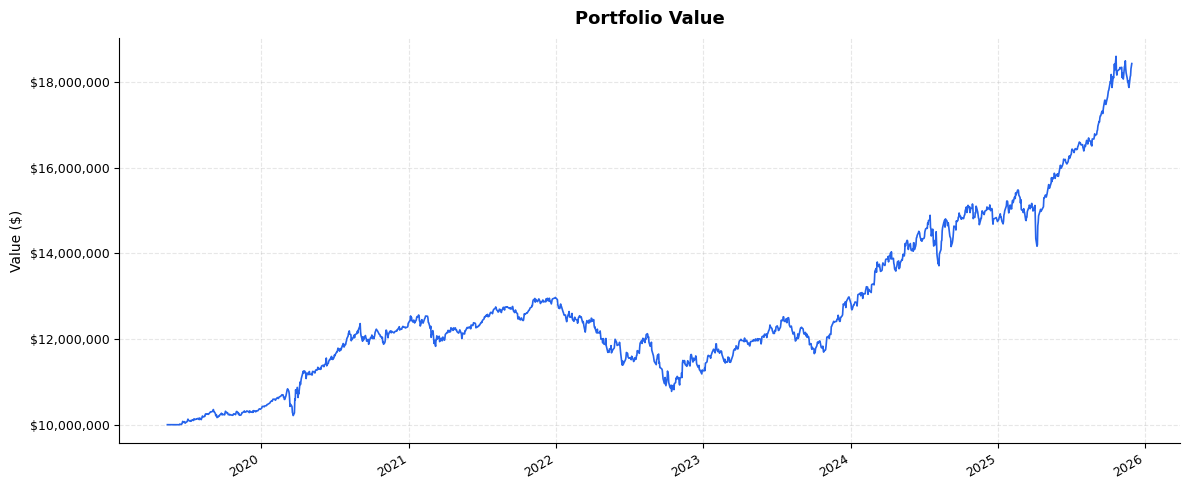

/Users/hyx/miniconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


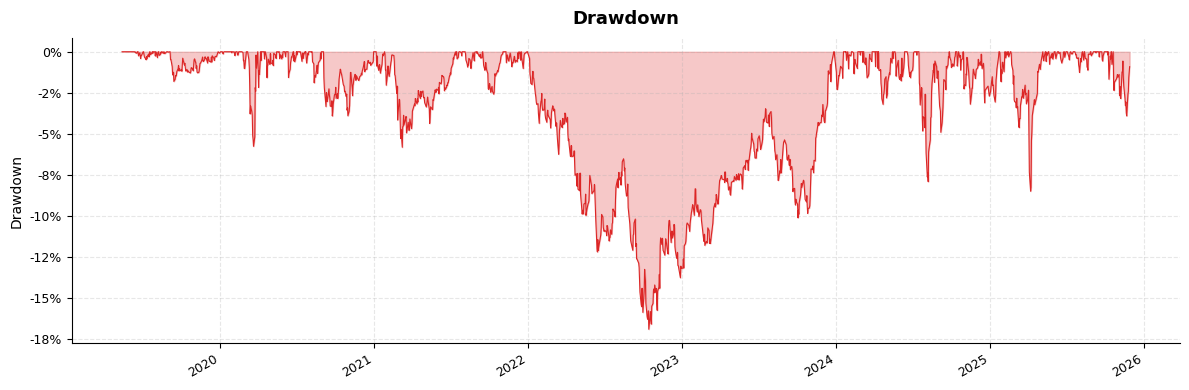

In [5]:
if grid_result.best_backtest:
    grid_result.best_backtest.print_summary()
    grid_result.best_backtest.plot_value()
    grid_result.best_backtest.plot_drawdown()

# 3. Random Search (larger space)

In [6]:
from src.backtesting import RandomParameterGrid

random_optimizer = GridSearchOptimizer(
    strategy_cls=MertonFullStrategy,
    param_grid=RandomParameterGrid(
        {
            "gamma": [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
            "max_risky_fraction": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
            "top_n": [3, 4, 5, 6, 7],
            "band_scale": [0.5, 1.0, 1.5, 2.0, 3.0],
            "rebalance_every": [10, 15, 21, 42],
        },
        n_samples=30,
        seed=42,
    ),
    metric="sharpe_ratio",
    warmup_size=252,
    base_strategy_kwargs={
        "defensive_ticker": "XEON.DE",
        "mu_estimator": JamesSteinMean(),
        "cov_estimator": LedoitWolfCovariance(),
        "use_dn_bands": True,
    },
)

random_result = random_optimizer.optimize(
    universe=universe,
    history=history,
    portfolio_factory=lambda: Portfolio(initial_cash=10_000_000),
)

[1/30] Testing {'gamma': 0.3, 'max_risky_fraction': 0.5, 'top_n': 5, 'band_scale': 1.0, 'rebalance_every': 15}
  New best: sharpe_ratio=1.1471
[2/30] Testing {'gamma': 0.4, 'max_risky_fraction': 1.0, 'top_n': 3, 'band_scale': 3.0, 'rebalance_every': 10}
[3/30] Testing {'gamma': 0.8, 'max_risky_fraction': 0.5, 'top_n': 3, 'band_scale': 0.5, 'rebalance_every': 15}
[4/30] Testing {'gamma': 0.5, 'max_risky_fraction': 0.9, 'top_n': 7, 'band_scale': 0.5, 'rebalance_every': 15}
  New best: sharpe_ratio=1.2015
[5/30] Testing {'gamma': 0.8, 'max_risky_fraction': 0.6, 'top_n': 6, 'band_scale': 3.0, 'rebalance_every': 21}
[6/30] Testing {'gamma': 0.2, 'max_risky_fraction': 0.6, 'top_n': 6, 'band_scale': 1.5, 'rebalance_every': 21}
[7/30] Testing {'gamma': 0.4, 'max_risky_fraction': 0.6, 'top_n': 5, 'band_scale': 0.5, 'rebalance_every': 10}
  New best: sharpe_ratio=1.2018
[8/30] Testing {'gamma': 0.8, 'max_risky_fraction': 0.5, 'top_n': 5, 'band_scale': 1.5, 'rebalance_every': 21}
[9/30] Testing {

In [7]:
print(f"Best params: {random_result.best_params}")
print(f"Best {random_optimizer.metric}: {random_result.best_metric:.4f}")
print()

random_df = pd.DataFrame([
    {**params, random_optimizer.metric: metric}
    for params, metric in random_result.all_results
]).sort_values(random_optimizer.metric, ascending=False)

random_df.head(10)

Best params: {'gamma': 0.4, 'max_risky_fraction': 0.6, 'top_n': 5, 'band_scale': 0.5, 'rebalance_every': 10}
Best sharpe_ratio: 1.2018



,gamma,max_risky_fraction,top_n,band_scale,rebalance_every,sharpe_ratio
6,0.4,0.6,5,0.5,10,1.201789
3,0.5,0.9,7,0.5,15,1.201486
16,0.2,0.7,6,1.5,10,1.192362
27,0.3,1.0,5,3.0,15,1.191703
15,0.5,1.0,5,0.5,15,1.189655
19,0.4,0.6,7,3.0,21,1.187306
21,0.4,0.9,6,0.5,10,1.187251
13,0.7,0.6,5,0.5,15,1.185144
23,0.8,0.8,7,2.0,21,1.175990
20,0.8,0.9,6,1.5,15,1.172645


# 4. Walk-Forward Optimization

In [8]:
from src.backtesting import WalkForwardOptimizer

wf_optimizer = WalkForwardOptimizer(
    strategy_cls=MertonFullStrategy,
    param_grid=ParameterGrid({
        "gamma": [0.3, 0.5, 0.8],
        "max_risky_fraction": [0.6, 0.8],
    }),
    metric="sharpe_ratio",
    train_size=504,      # 2 years train
    test_size=126,       # 6 months test
    step_size=126,       # non-overlapping
    base_strategy_kwargs={
        "defensive_ticker": "XEON.DE",
        "mu_estimator": JamesSteinMean(),
        "cov_estimator": LedoitWolfCovariance(),
        "rebalance_every": 21,
        "use_dn_bands": True,
        "band_scale": 2.0,
        "top_n": 5,
    },
)

wf_result = wf_optimizer.run(
    universe=universe,
    full_history=history,
    portfolio_factory=lambda: Portfolio(initial_cash=10_000_000),
)

Walk-Forward: 10 windows, 6 combos each
Window 1/10
[1/6] Testing {'gamma': 0.3, 'max_risky_fraction': 0.6}
  New best: sharpe_ratio=1.2338
[2/6] Testing {'gamma': 0.3, 'max_risky_fraction': 0.8}
[3/6] Testing {'gamma': 0.5, 'max_risky_fraction': 0.6}
  New best: sharpe_ratio=1.2351
[4/6] Testing {'gamma': 0.5, 'max_risky_fraction': 0.8}
[5/6] Testing {'gamma': 0.8, 'max_risky_fraction': 0.6}
[6/6] Testing {'gamma': 0.8, 'max_risky_fraction': 0.8}
Window 2/10
[1/6] Testing {'gamma': 0.3, 'max_risky_fraction': 0.6}
  New best: sharpe_ratio=1.0321
[2/6] Testing {'gamma': 0.3, 'max_risky_fraction': 0.8}
[3/6] Testing {'gamma': 0.5, 'max_risky_fraction': 0.6}
[4/6] Testing {'gamma': 0.5, 'max_risky_fraction': 0.8}
[5/6] Testing {'gamma': 0.8, 'max_risky_fraction': 0.6}
  New best: sharpe_ratio=1.0399
[6/6] Testing {'gamma': 0.8, 'max_risky_fraction': 0.8}
Window 3/10
[1/6] Testing {'gamma': 0.3, 'max_risky_fraction': 0.6}
  New best: sharpe_ratio=0.6039
[2/6] Testing {'gamma': 0.3, 'max_ri

In [9]:
print(f"Windows: {len(wf_result.windows)}")
print(f"OOS/IS ratio: {wf_result.oos_is_ratio:.2f}" if wf_result.oos_is_ratio else "OOS/IS ratio: N/A")
print(f"Combined OOS metrics:")
for k, v in wf_result.combined_metrics.items():
    print(f"  {k}: {v:.4f}")

Windows: 10
OOS/IS ratio: 0.14
Combined OOS metrics:
  total_return: 0.0644
  annualized_return: 0.0126
  annualized_volatility: 0.1031
  sharpe_ratio: 0.1219
  max_drawdown: -0.1694
  calmar_ratio: 0.0742


In [10]:
wf_result.params_over_time

,window,test_start,test_end,train_metric,gamma,max_risky_fraction
0,0,2020-10-05,2021-04-12,1.235058,0.5,0.6
1,1,2021-04-13,2021-10-13,1.039856,0.8,0.6
2,2,2021-10-14,2022-04-21,0.663932,0.8,0.6
3,3,2022-04-22,2022-10-27,1.211156,0.5,0.6
4,4,2022-10-28,2023-05-04,0.512656,0.3,0.8
5,5,2023-05-05,2023-11-06,0.035103,0.5,0.8
6,6,2023-11-07,2024-05-14,-0.357113,0.3,0.6
7,7,2024-05-15,2024-11-13,0.779769,0.5,0.8
8,8,2024-11-14,2025-05-28,1.965256,0.8,0.8
9,9,2025-05-29,2025-11-28,1.397056,0.3,0.6


In [11]:
wf_result.summary()

,window,train_start,train_end,test_start,test_end,train_metric,test_return,test_sharpe,param_gamma,param_max_risky_fraction
0,0,2018-09-07,2020-10-02,2020-10-05,2021-04-12,1.235058,-0.019739,-0.571691,0.5,0.6
1,1,2019-03-18,2021-04-12,2021-04-13,2021-10-13,1.039856,0.036114,1.905533,0.8,0.6
2,2,2019-09-23,2021-10-13,2021-10-14,2022-04-21,0.663932,-0.041839,-1.352668,0.8,0.6
3,3,2020-03-30,2022-04-21,2022-04-22,2022-10-27,1.211156,-0.032529,-0.647563,0.5,0.6
4,4,2020-10-05,2022-10-27,2022-10-28,2023-05-04,0.512656,-0.033774,-1.057819,0.3,0.8
5,5,2021-04-13,2023-05-04,2023-05-05,2023-11-06,0.035103,0.006105,0.194280,0.5,0.8
6,6,2021-10-14,2023-11-06,2023-11-07,2024-05-14,-0.357113,0.116483,3.287791,0.3,0.6
7,7,2022-04-22,2024-05-14,2024-05-15,2024-11-13,0.779769,0.072523,1.434300,0.5,0.8
8,8,2022-10-28,2024-11-13,2024-11-14,2025-05-28,1.965256,0.040051,0.709917,0.8,0.8
9,9,2023-05-05,2025-05-28,2025-05-29,2025-11-28,1.397056,0.064424,2.233801,0.3,0.6


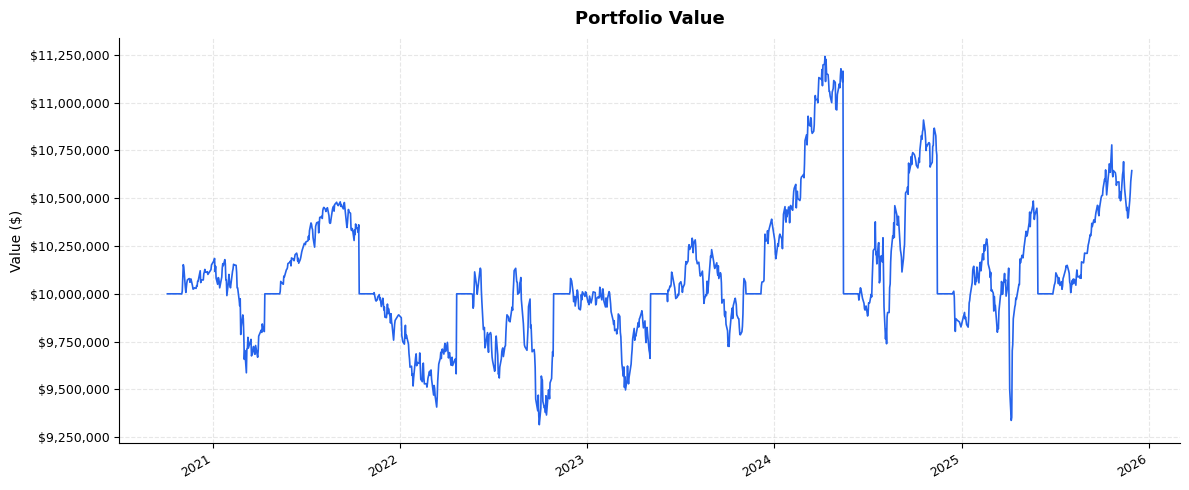

/Users/hyx/miniconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


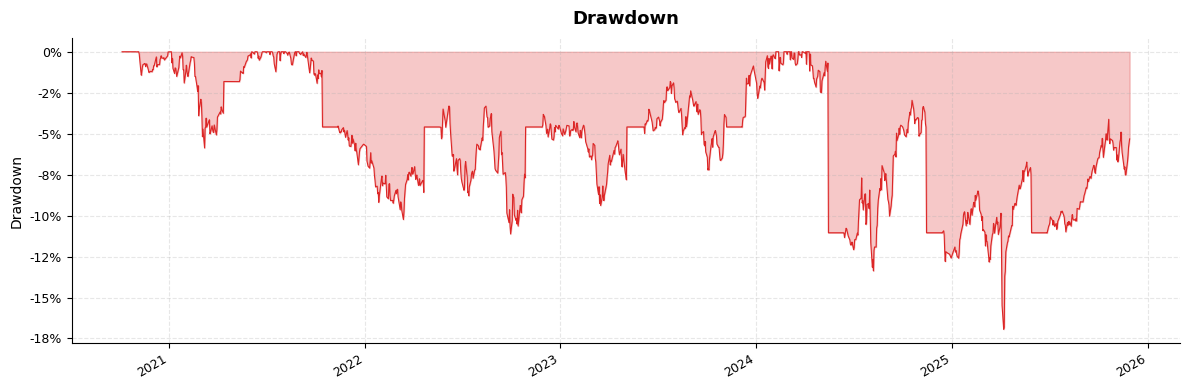

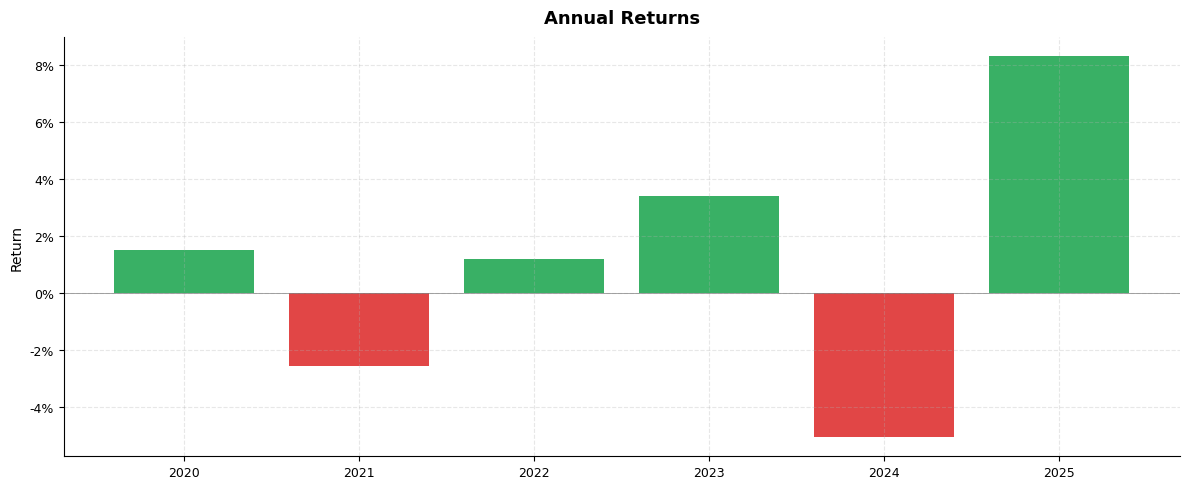

In [12]:
wf_result.combined.plot_value()
wf_result.combined.plot_drawdown()
wf_result.combined.plot_annual_returns()

# 5. Compare: Best Grid vs Best WF vs Buy & Hold

In [13]:
from src.strategy.buy_and_hold import BuyAndHoldStrategy
from src.backtesting import Backtest

# Best grid params
best_grid = MertonFullStrategy(
    universe=universe,
    name="grid_best",
    defensive_ticker="XEON.DE",
    mu_estimator=JamesSteinMean(),
    cov_estimator=LedoitWolfCovariance(),
    use_dn_bands=True,
    band_scale=2.0,
    **grid_result.best_params,
)

bnh = BuyAndHoldStrategy(universe=universe)

comparison = Backtest(
    portfolio=Portfolio(initial_cash=10_000_000),
    universe=universe,
    strategies=[best_grid, bnh],
    history=history,
    warmup_size=252,
).run()

comparison.summary_df[["total_return", "annualized_return", "sharpe_ratio", "max_drawdown", "total_costs"]].round(4)

,total_return,annualized_return,sharpe_ratio,max_drawdown,total_costs
grid_best,0.8431,0.1010,1.1407,-0.1691,17183.0190
buy_and_hold,1.3142,0.1411,0.8980,-0.2773,2575.8877


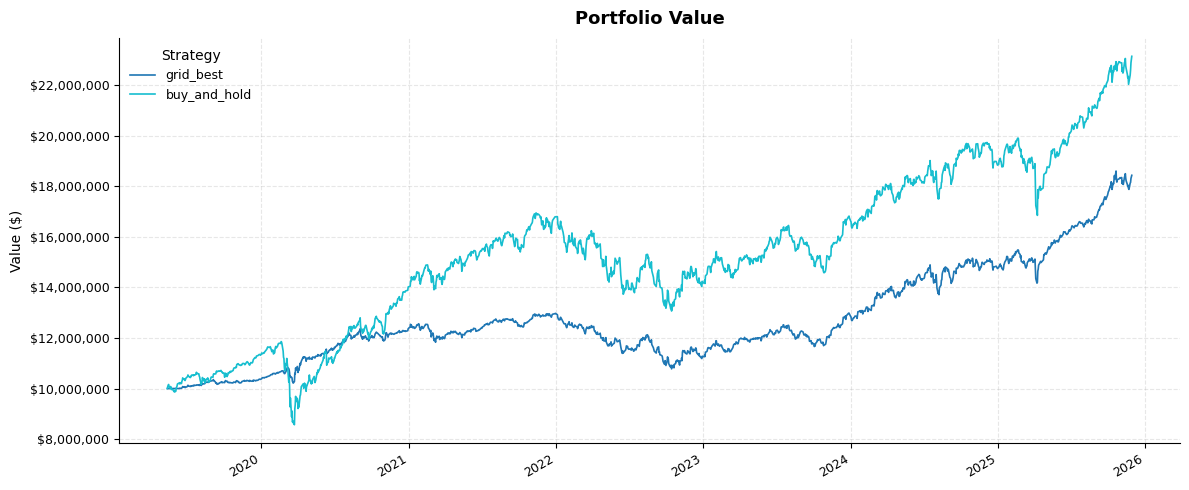

/Users/hyx/miniconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


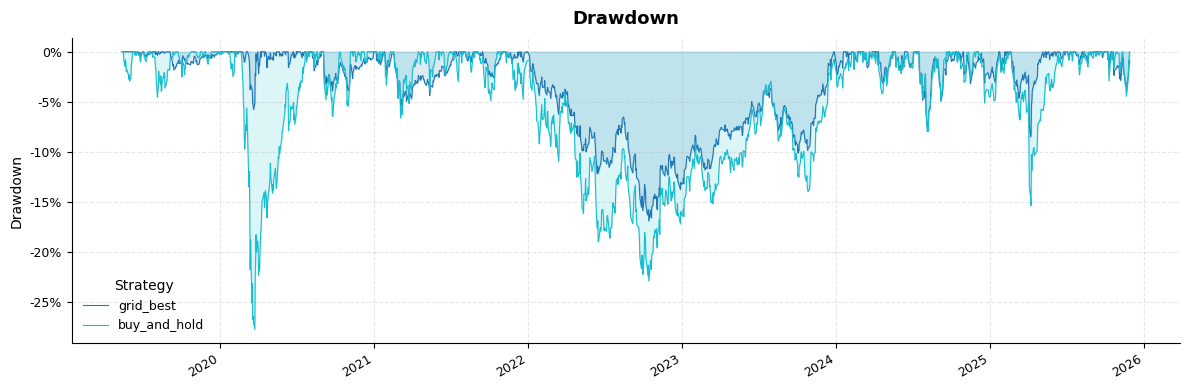

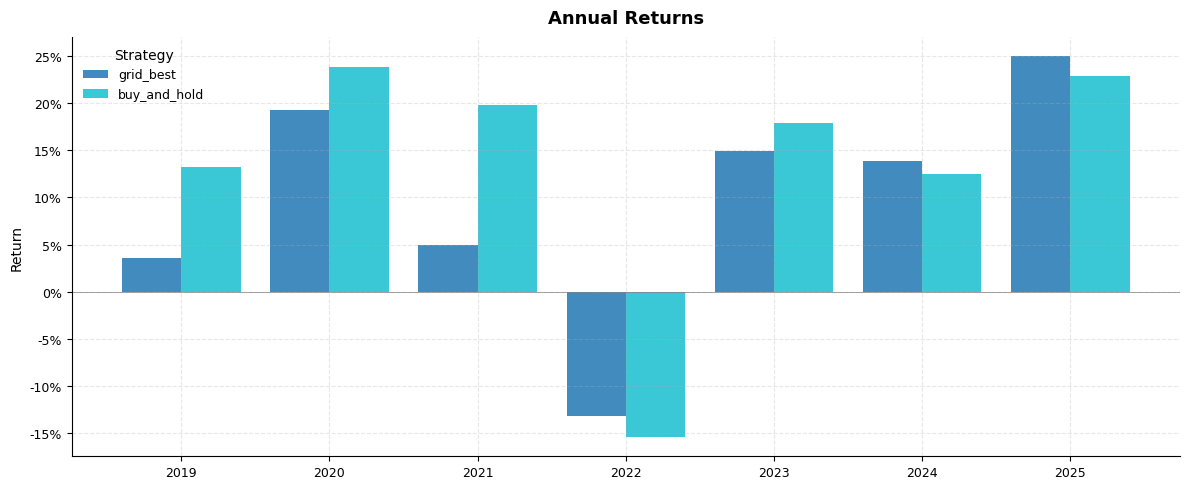

In [14]:
comparison.plot_value()
comparison.plot_drawdown()
comparison.plot_annual_returns()